In [ ]:
import torch
# step1: prepare dataset
# x,y是矩阵，3行1列 也就是说总共有3个样本，每个样本只有1个特征
x_data = torch.tensor([[1.0], [2.0], [3.0]])
y_data = torch.tensor([[2.0], [4.0], [6.0]])
 
# step2: design model using class
"""
our model class should be inherit from nn.Module, which is base class for all neural network modules.
member methods __init__() and forward() have to be implemented
class nn.linear contain two member Tensors: weight and bias
class nn.Linear has implemented the magic method __call__(),which enable the instance of the class can
be called just like a function.Normally the forward() will be called 
"""
class LinearModel(torch.nn.Module):
    def __init__(self):
        super(LinearModel, self).__init__()
        # (1,1)是指输入x和输出y的特征维度，这里数据集中的x和y的特征都是1维的
        # 该线性层需要学习的参数是w和b  获取w/b的方式分别是~linear.weight/linear.bias
        self.linear = torch.nn.Linear(1, 1)
 
    def forward(self, x):
        y_pred = self.linear(x)
        return y_pred
 
model = LinearModel()
 
# step3: construct loss and optimizer
# criterion = torch.nn.MSELoss(size_average = False)
criterion = torch.nn.MSELoss(reduction = 'sum')    # 计算所有样本的损失
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)    # SGD 更新参数
 
# step4: training cycle forward, backward, update
for epoch in range(100):
    y_pred = model(x_data) # forward:predict
    loss = criterion(y_pred, y_data) # forward: loss
    print(epoch, loss.item())
 
    optimizer.zero_grad() # the grad computer by .backward() will be accumulated. so before backward, remember set the grad to zero
    loss.backward() # backward: autograd，自动计算梯度
    optimizer.step() # update 参数，即更新w和b的值
 
print('w = ', model.linear.weight.item())
print('b = ', model.linear.bias.item())
 
x_test = torch.tensor([[4.0]])
y_test = model(x_test)
print('y_pred = ', y_test.data)

0 104.66204833984375
1 46.98006820678711
2 21.296127319335938
3 9.856878280639648
4 4.759037494659424
5 2.4842915534973145
6 1.466384768486023
7 1.0080604553222656
8 0.7989214658737183
9 0.7007871270179749
10 0.6521400809288025
11 0.6255950927734375
12 0.6089596748352051
13 0.5968050956726074
14 0.5867130756378174
15 0.5776064991950989
16 0.5690048933029175
17 0.5606938600540161
18 0.5525762438774109
19 0.5446078777313232
20 0.5367695689201355
21 0.5290502309799194
22 0.5214444398880005
23 0.5139490365982056
24 0.5065627694129944
25 0.4992820620536804
26 0.4921066164970398
27 0.4850339889526367
28 0.47806328535079956
29 0.4711928367614746
30 0.4644213914871216
31 0.4577464759349823
32 0.45116811990737915
33 0.44468429684638977
34 0.43829312920570374
35 0.4319944977760315
36 0.4257860779762268
37 0.41966676712036133
38 0.4136354923248291
39 0.4076912999153137
40 0.4018317759037018
41 0.3960568904876709
42 0.39036500453948975
43 0.3847547471523285
44 0.3792251646518707
45 0.3737752437591

### homework
不同优化器更新参数的差别可视化

SGD          | final loss=0.046586 | w=1.7499, b=0.5685
SGD+Momentum | final loss=0.000000 | w=1.9995, b=0.0012
Adam         | final loss=0.247896 | w=1.4125, b=1.3024
RMSprop      | final loss=0.592681 | w=1.0795, b=1.6903
Adagrad      | final loss=1.194553 | w=0.9038, b=1.5745


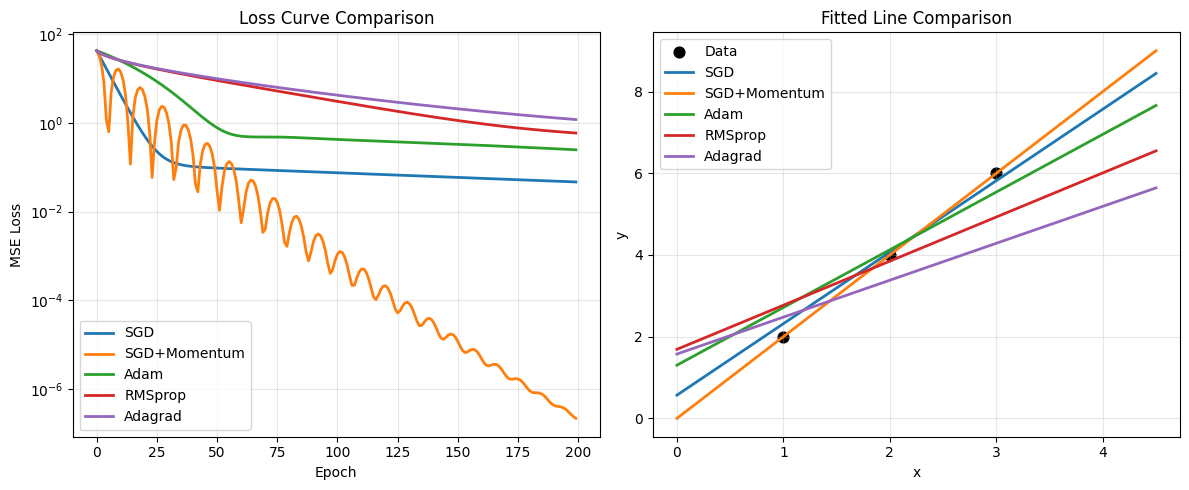

In [ ]:
import torch
import matplotlib.pyplot as plt
import copy

# =========================
# 1) 准备数据
# =========================
x_data = torch.tensor([[1.0], [2.0], [3.0]])
y_data = torch.tensor([[2.0], [4.0], [6.0]])

# =========================
# 2) 定义模型
# =========================
class LinearModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = torch.nn.Linear(1, 1)   # 输入和输出的特征维度均为1，自动包含 w 和 b
    def forward(self, x):
        return self.linear(x)    # 直接调用线性层，完成线性模型的前向传播 y = xw + b 

# =========================
# 3) 训练函数：给定优化器类型，返回 loss 曲线和最终模型
# =========================
def train_with_optimizer(optimizer_name, lr=0.01, epochs=200):
    # 固定随机种子，保证每个优化器从同样初始参数起步（公平比较）
    torch.manual_seed(1234)
    model = LinearModel()    # 创建模型实例
    criterion = torch.nn.MSELoss(reduction="mean")

    # 选择优化器
    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "SGD+Momentum":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "RMSprop":
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr)
    elif optimizer_name == "Adagrad":
        optimizer = torch.optim.Adagrad(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    losses = []
    for _ in range(epochs):
        y_pred = model(x_data)
        loss = criterion(y_pred, y_data)
        # 先进行梯度清零，清除上一次迭代累计的梯度，然后反向传播计算梯度，然后更新参数
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return model, losses

# =========================
# 4) 配置要比较的优化器
# =========================
optimizers_config = {
    "SGD": {"lr": 0.01},
    "SGD+Momentum": {"lr": 0.01},
    "Adam": {"lr": 0.05},
    "RMSprop": {"lr": 0.01},
    "Adagrad": {"lr": 0.1},
}

results = {}
for opt_name, cfg in optimizers_config.items():
    model, losses = train_with_optimizer(opt_name, lr=cfg["lr"], epochs=200)
    w = model.linear.weight.item()
    b = model.linear.bias.item()
    results[opt_name] = {
        "model": model,
        "losses": losses,
        "w": w,
        "b": b,
    }
    print(f"{opt_name:12s} | final loss={losses[-1]:.6f} | w={w:.4f}, b={b:.4f}")

# =========================
# 5) 可视化比较（同一张图中两个子图）
# =========================
plt.figure(figsize=(12, 5))
# 子图1：Loss 曲线比较
plt.subplot(1, 2, 1)
for opt_name, info in results.items():
    plt.plot(info["losses"], label=opt_name, linewidth=2)
plt.title("Loss Curve Comparison")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.yscale("log")  # 对数坐标更清楚
plt.grid(alpha=0.3)
plt.legend()
# 子图2：最终拟合直线比较
plt.subplot(1, 2, 2)
plt.scatter(x_data.numpy(), y_data.numpy(), color="black", s=60, label="Data")
x_plot = torch.linspace(0.0, 4.5, 100).reshape(-1, 1)
for opt_name, info in results.items():
    y_plot = info["model"](x_plot).detach().numpy()
    plt.plot(x_plot.numpy(), y_plot, linewidth=2, label=opt_name)
plt.title("Fitted Line Comparison")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
